In [25]:
from dataVisual import src_img_print,load_images,print_image
from pca import standarize,standarize_bulk,pca
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random

PATH = './data/caras.csv'
df = pd.read_csv(PATH)

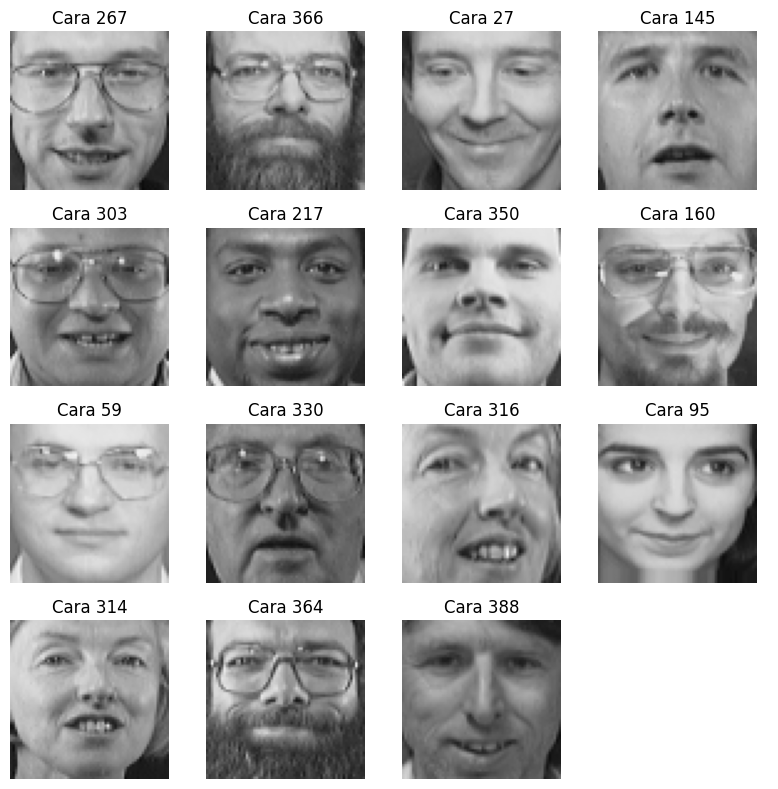

In [26]:
src_img_print(PATH,15)

In [27]:
persons_ids = df['person_id'].to_numpy(dtype=int)
persons = np.bincount(persons_ids)
print(persons_ids)
print(f"hay {len(persons)} personas distintas")
print(persons)

[ 0  0  0  0  0  0  0  0  0  0  1  1  1  1  1  1  1  1  1  1  2  2  2  2
  2  2  2  2  2  2  3  3  3  3  3  3  3  3  3  3  4  4  4  4  4  4  4  4
  4  4  5  5  5  5  5  5  5  5  5  5  6  6  6  6  6  6  6  6  6  6  7  7
  7  7  7  7  7  7  7  7  8  8  8  8  8  8  8  8  8  8  9  9  9  9  9  9
  9  9  9  9 10 10 10 10 10 10 10 10 10 10 11 11 11 11 11 11 11 11 11 11
 12 12 12 12 12 12 12 12 12 12 13 13 13 13 13 13 13 13 13 13 14 14 14 14
 14 14 14 14 14 14 15 15 15 15 15 15 15 15 15 15 16 16 16 16 16 16 16 16
 16 16 17 17 17 17 17 17 17 17 17 17 18 18 18 18 18 18 18 18 18 18 19 19
 19 19 19 19 19 19 19 19 20 20 20 20 20 20 20 20 20 20 21 21 21 21 21 21
 21 21 21 21 22 22 22 22 22 22 22 22 22 22 23 23 23 23 23 23 23 23 23 23
 24 24 24 24 24 24 24 24 24 24 25 25 25 25 25 25 25 25 25 25 26 26 26 26
 26 26 26 26 26 26 27 27 27 27 27 27 27 27 27 27 28 28 28 28 28 28 28 28
 28 28 29 29 29 29 29 29 29 29 29 29 30 30 30 30 30 30 30 30 30 30 31 31
 31 31 31 31 31 31 31 31 32 32 32 32 32 32 32 32 32

Se puede ver que tengo 10 imagenes por cada una de las 40 personas, y estan ordenadas

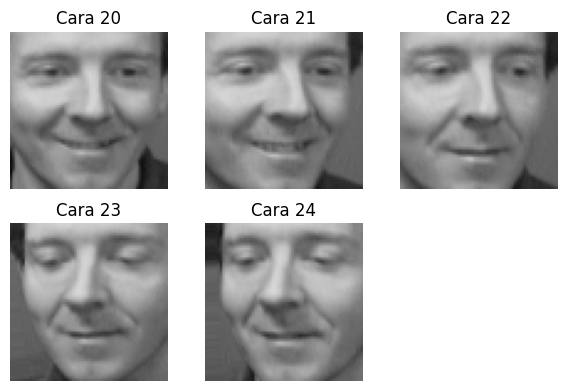

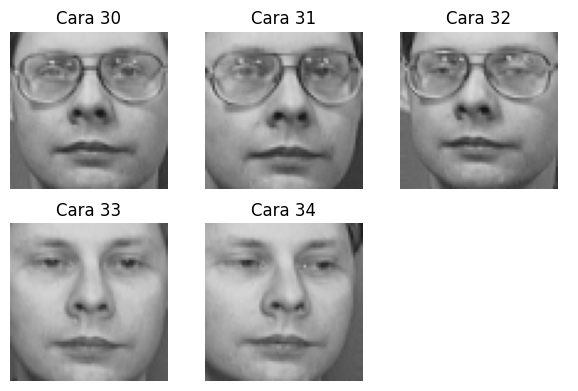

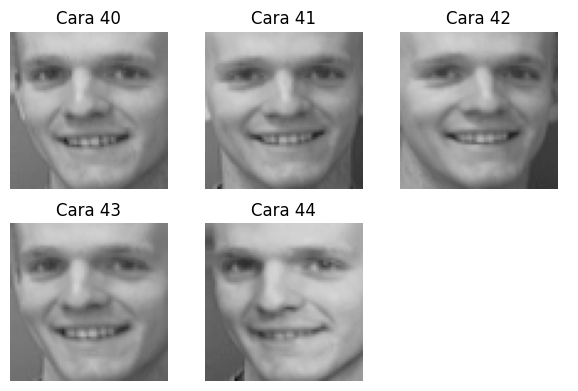

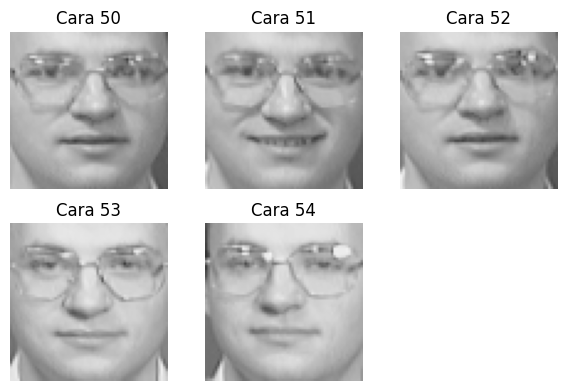

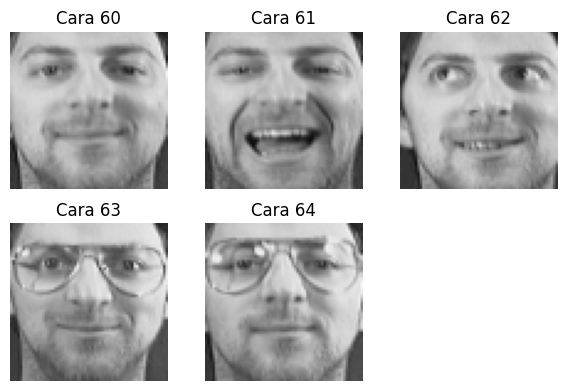

In [28]:
src_img_print(PATH,5,rand=False,start_id=2)
src_img_print(PATH,5,rand=False,start_id=3)
src_img_print(PATH,5,rand=False,start_id=4)
src_img_print(PATH,5,rand=False,start_id=5)
src_img_print(PATH,5,rand=False,start_id=6)

In [29]:
images = load_images(PATH,64)
print(f"cantidad total de imagenes: {len(images)}")
train = []
train_val = []
test = []
test_val = []
photo = 0
person = 0
for idx in range(len(images)):
        if photo < 2:
            test.append(images[idx])
            test_val.append(persons_ids[idx])
        else:
            train.append(images[idx])
            train_val.append(persons_ids[idx])
        photo = (photo+1)%10

full_test = list(zip(test,test_val))
random.shuffle(full_test)
test, test_val = map(list, zip(*full_test))

full_train = list(zip(train,train_val))
random.shuffle(full_train)
train, train_val = map(list, zip(*full_train))

print(f"tamano de train: {len(train)}\ntamano de test: {len(test)}")

cantidad total de imagenes: 400
tamano de train: 320
tamano de test: 80


Separe dos fotos de cada cara para test, El resto fue a train. y se mezclaron las ambos arreglos de caras.

In [30]:
import numpy as np

# --- Celda de Split de Datos ---
# --- Parámetros de la división ---
TEST_SIZE_RATIO = 0.2  # 20% para 'test' (80 muestras)
RANDOM_SEED = 42
    
n_samples = len(images)

# --- Crear los índices y mezclarlos ---
np.random.seed(RANDOM_SEED)
indices = np.arange(n_samples)
np.random.shuffle(indices)

n_test = int(n_samples * TEST_SIZE_RATIO)

test_indices = indices[:n_test]
train_indices = indices[n_test:]

train = images[train_indices]
test = images[test_indices]

y_train = persons_ids[train_indices]
y_test = persons_ids[test_indices]

print(f"Shape de 'train' (imágenes): {train.shape}")
print(f"Shape de 'y_train' (labels):  {y_train.shape}")
print(f"Shape de 'test' (imágenes):  {test.shape}")
print(f"Shape de 'y_test' (labels):  {y_test.shape}")


Shape de 'train' (imágenes): (320, 64, 64)
Shape de 'y_train' (labels):  (320,)
Shape de 'test' (imágenes):  (80, 64, 64)
Shape de 'y_test' (labels):  (80,)


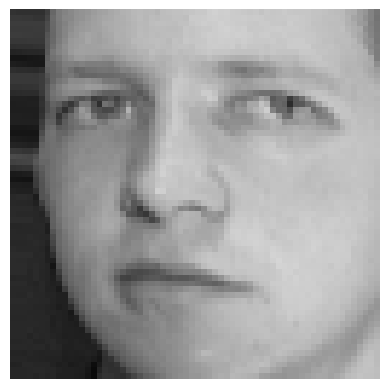

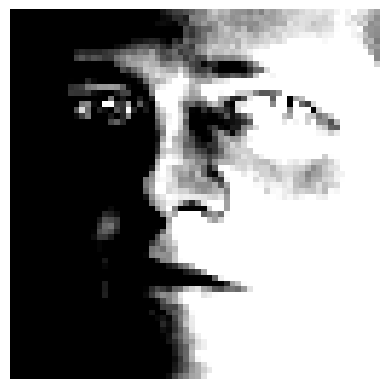

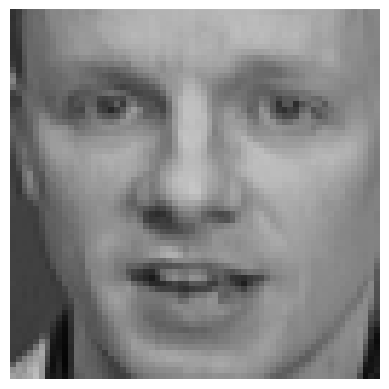

k=113 | MSE train=0.000967


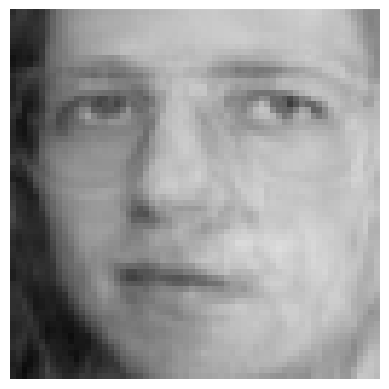

Imagen original:


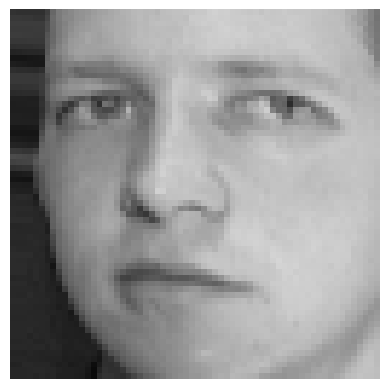

Imagen luego de PCA:


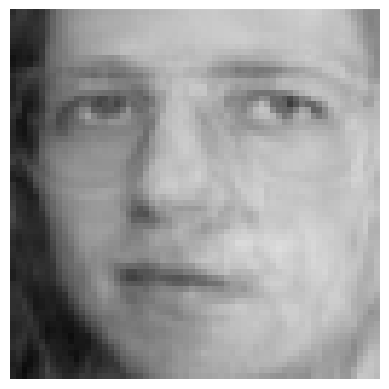

Varianza original: 4096.0
Varianza luego de PCA: 73.787109375
Porcentaje de varianza retenida luego de PCA: 1.801443099975586%


In [31]:
mean = np.mean(train,axis=0)
std = np.std(train,axis=0)
print_image(train[0])
standarize(train[0],mean,std,print=True)
train_std = standarize_bulk(train,mean,std)
print_image(test[0])
compress_dataset = pca(train_std,train,mean,std)
print_image(compress_dataset[0])
#comparar el antes y el despues del pca en una imagen
print("Imagen original:")
print_image(train[0])
print("Imagen luego de PCA:")
print_image(compress_dataset[0])
#metrica para demostrar el cambio
original_var = np.var(train_std,axis=0).sum()
pca_var = np.var(compress_dataset,axis=0).sum()
print(f"Varianza original: {original_var}\nVarianza luego de PCA: {pca_var}")
print(f"Porcentaje de varianza retenida luego de PCA: {pca_var/original_var*100}%")


Componentes necesarios para ≥90% de la varianza: 63
Varianza acumulada con 63 componentes: 0.9006


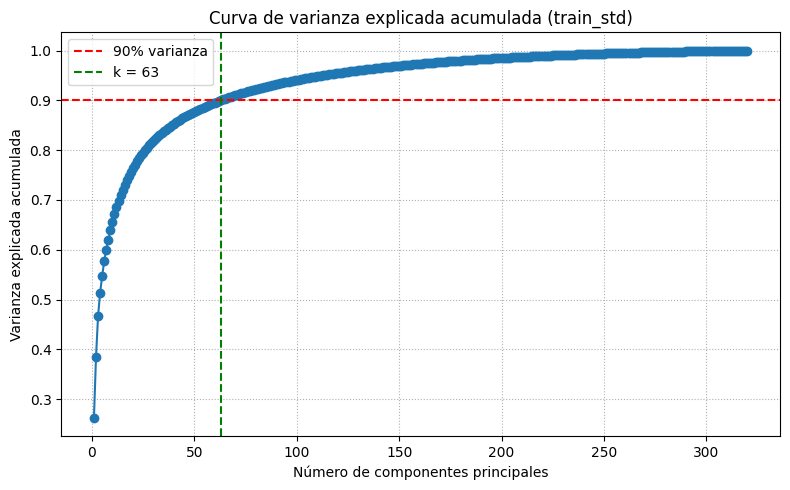

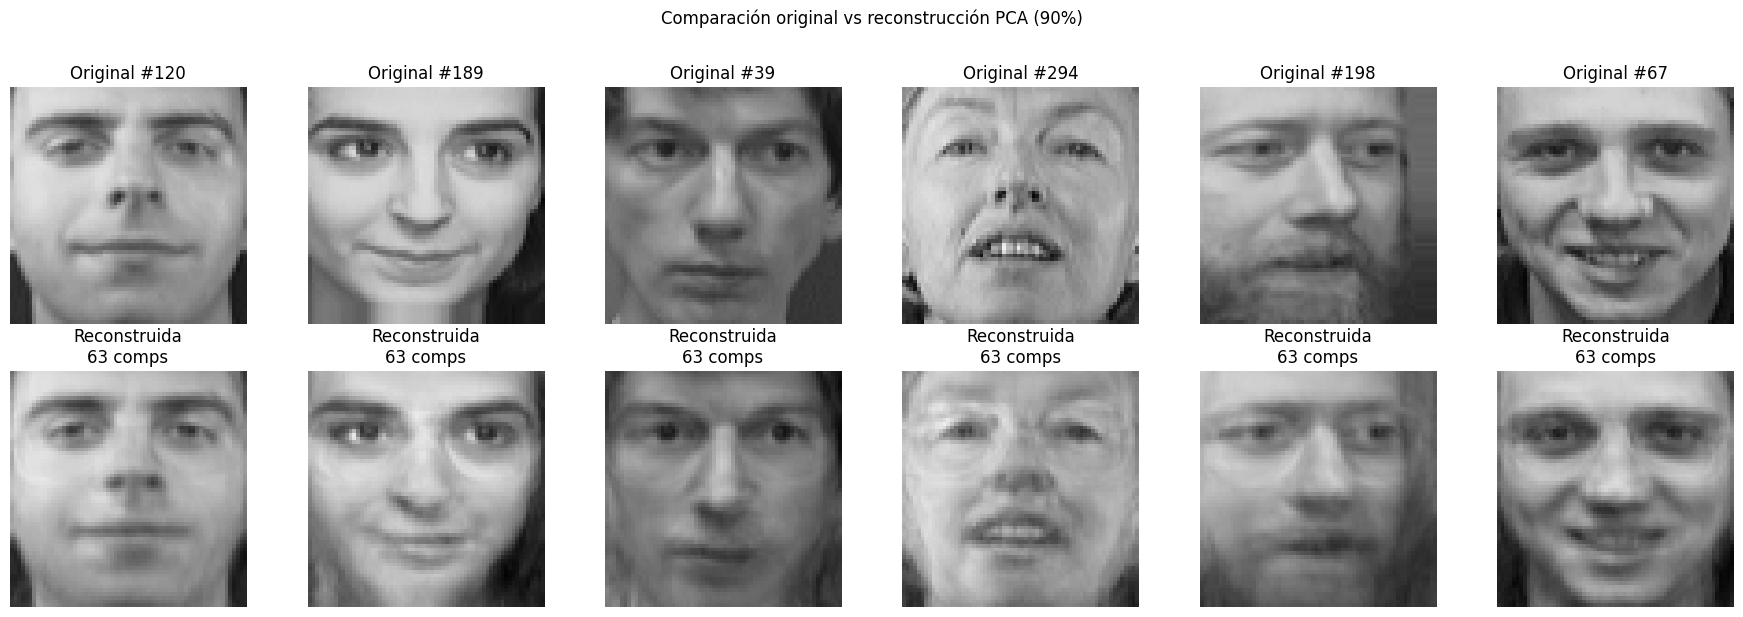

In [32]:
# Cálculo de la varianza explicada acumulada
X = train_std.reshape(len(train_std), -1)
n_samples = X.shape[0]

U, S, Vt = np.linalg.svd(X, full_matrices=False)
explained_variance = (S ** 2) / (n_samples - 1)
explained_ratio = explained_variance / explained_variance.sum()
cumulative_ratio = np.cumsum(explained_ratio)

k_90 = np.searchsorted(cumulative_ratio, 0.90) + 1
print(f"Componentes necesarios para ≥90% de la varianza: {k_90}")
print(f"Varianza acumulada con {k_90} componentes: {cumulative_ratio[k_90-1]:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(cumulative_ratio) + 1), cumulative_ratio, marker="o")
plt.axhline(0.90, color="red", linestyle="--", label="90% varianza")
plt.axvline(k_90, color="green", linestyle="--", label=f"k = {k_90}")
plt.xlabel("Número de componentes principales")
plt.ylabel("Varianza explicada acumulada")
plt.title("Curva de varianza explicada acumulada (train_std)")
plt.grid(True, linestyle=":")
plt.legend()
plt.tight_layout()
plt.show()

# Reconstrucción con k componentes
Wk = Vt[:k_90].T
Z = X @ Wk
X_rec_std = Z @ Wk.T

mean_flat = mean.reshape(-1)
std_flat = np.where(std.reshape(-1) == 0, 1.0, std.reshape(-1))
X_rec = (X_rec_std * std_flat) + mean_flat
train_rec = X_rec.reshape((-1,) + mean.shape)

# Comparativa visual
muestras = np.random.choice(len(train), size=6, replace=False)

fig, axes = plt.subplots(2, len(muestras), figsize=(3 * len(muestras), 6))
for col, idx in enumerate(muestras):
    axes[0, col].imshow(train[idx], cmap="gray", vmin=0, vmax=1)
    axes[0, col].set_title(f"Original #{idx}")
    axes[0, col].axis("off")

    axes[1, col].imshow(train_rec[idx], cmap="gray", vmin=0, vmax=1)
    axes[1, col].set_title(f"Reconstruida\n{k_90} comps")
    axes[1, col].axis("off")

plt.suptitle("Comparación original vs reconstrucción PCA (90%)", y=1.02)
plt.tight_layout()
plt.show()

In [33]:
# --- Guardar el modelo PCA ---
#
# Esta celda guarda las variables clave que definen tu transformación PCA
# en un solo archivo comprimido (.npz) usando NumPy.
#
# Variables a guardar:
#   - mean: La imagen media de 'train' (ej: forma (64, 64))
#   - std:  La imagen de desv. estándar de 'train' (ej: forma (64, 64))
#   - Wk:   La matriz de componentes principales (ej: forma (4096, 62))
#   - k:    El número de componentes guardados (ej: 62)

try:
    print(f" - Forma de 'mean': {mean.shape}")
    print(f" - Forma de 'std': {std.shape}")
    print(f" - Forma de 'Wk' (componentes): {Wk.shape}")
    print(f" - Número de componentes 'k': {k_90}")

    # Guardamos los arrays en un archivo .npz
    np.savez(
        'modelo_pca.npz',
        mean=mean,
        std=std,
        Wk=Wk,
        k=k_90
    )
    
    print("El modelo PCA se ha guardado correctamente en 'modelo_pca.npz'")

except NameError as e:
    print(f"ERROR")
    print(f"No se pudo encontrar una de las variables: {e}")
except Exception as e:
    print(f"Ocurrió un error inesperado al guardar: {e}")

 - Forma de 'mean': (64, 64)
 - Forma de 'std': (64, 64)
 - Forma de 'Wk' (componentes): (4096, 63)
 - Número de componentes 'k': 63
El modelo PCA se ha guardado correctamente en 'modelo_pca.npz'


In [34]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import numpy as np

# --- OPTIMIZACIÓN DE HARDWARE (CUDA) ---
# GPU (RTX 3070)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo seleccionado: {device}")
if torch.cuda.is_available():
    print(f"Nombre de la GPU: {torch.cuda.get_device_name(0)}")
scaler = torch.amp.GradScaler('cuda',enabled=(device.type == 'cuda'))
print(f"AMP activado: {scaler.is_enabled()}")

Dispositivo seleccionado: cuda
Nombre de la GPU: NVIDIA GeForce RTX 3070
AMP activado: True


In [35]:
class ConvolutionalAutoencoder(nn.Module):
    def __init__(self, latent_dim):
        super(ConvolutionalAutoencoder, self).__init__()
        
        # --- Encoder ---
        self.encoder_conv = nn.Sequential(
            # Input: (N, 1, 64, 64)
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1), # -> (N, 16, 32, 32)
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # -> (N, 32, 16, 16)
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), # -> (N, 64, 8, 8)
            nn.ReLU()
        )
        
        # Capa lineal para el espacio latente
        self.encoder_fc = nn.Linear(64 * 8 * 8, latent_dim) # 64*8*8 = 4096
        
        # --- Decoder ---
        self.decoder_fc = nn.Linear(latent_dim, 64 * 8 * 8)
        
        self.decoder_conv = nn.Sequential(
            # Input: (N, 64, 8, 8)
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1), # -> (N, 32, 16, 16)
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1), # -> (N, 16, 32, 32)
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1) # -> (N, 1, 64, 64)
            
        )

    def encode(self, x):
        x = self.encoder_conv(x)
        x = x.view(x.size(0), -1) # Aplanar: (N, 64, 8, 8) -> (N, 4096)
        encoded = self.encoder_fc(x)
        return encoded

    def decode(self, z):
        x = self.decoder_fc(z)
        x = x.view(x.size(0), 64, 8, 8) # Reformar: (N, 4096) -> (N, 64, 8, 8)
        decoded = self.decoder_conv(x)
        return decoded

    def forward(self, x):
        encoded = self.encode(x)
        decoded = self.decode(encoded)
        return decoded

In [36]:
# --- Preparación de Datos ---

std_safe = np.where(std == 0, 1.0, std)
test_std = (test - mean) / std_safe

print(f"Variable 'test_std' creada exitosamente. Forma: {test_std.shape}")


# --- OPTIMIZACIÓN DE HARDWARE (CPU/DATALOADER) ---

# Reformar datos a (N, Canales, Alto, Ancho) -> (N, 1, 64, 64)
X_train_tensor = torch.tensor(train_std, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(test_std, dtype=torch.float32).unsqueeze(1)

# Crear TensorDataset
train_tensor_dataset = TensorDataset(X_train_tensor, X_train_tensor)
test_tensor_dataset = TensorDataset(X_test_tensor, X_test_tensor)

# Crear DataLoaders
BATCH_SIZE = 32
loader_args = {
    'batch_size': BATCH_SIZE,
    'num_workers': 10,  
    'pin_memory': True
}

train_loader = DataLoader(train_tensor_dataset, shuffle=True, **loader_args)
test_loader = DataLoader(test_tensor_dataset, shuffle=False, **loader_args)

print(f"\nDataLoaders listos con {loader_args['num_workers']} workers.")
print(f"Forma de los datos de entrenamiento: {X_train_tensor.shape}")
print(f"Forma de los datos de prueba: {X_test_tensor.shape}")

Variable 'test_std' creada exitosamente. Forma: (80, 64, 64)

DataLoaders listos con 10 workers.
Forma de los datos de entrenamiento: torch.Size([320, 1, 64, 64])
Forma de los datos de prueba: torch.Size([80, 1, 64, 64])


In [37]:
LATENT_DIM = k_90 
model_ae = ConvolutionalAutoencoder(latent_dim=LATENT_DIM).to(device)

criterion = nn.MSELoss() 
optimizer = optim.Adam(model_ae.parameters(), lr=1e-3)

print(f"Autoencoder CONVOLUCIONAL creado con {LATENT_DIM} dimensiones latentes.")
print(f"Modelo movido a: {next(model_ae.parameters()).device}")

Autoencoder CONVOLUCIONAL creado con 63 dimensiones latentes.
Modelo movido a: cuda:0


In [38]:
# --- Loop de Entrenamiento (con Early Stopping) ---

NUM_EPOCHS = 300
train_losses = []
test_losses = []

# -Early Stopping 
PATIENCE = 10  # Epochs a esperar antes de parar
best_test_loss = np.inf  # Empezamos con infinito
epochs_no_improve = 0
PATH_BEST_MODEL = "autoencoder_best.pth"

print("Iniciando entrenamiento...")
for epoch in range(NUM_EPOCHS):
    model_ae.train()
    running_train_loss = 0.0
    
    for (inputs, targets) in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        
        with torch.amp.autocast(device_type=device.type, dtype=torch.float16, enabled=(device.type == 'cuda')):
            outputs = model_ae(inputs)
            loss = criterion(outputs, targets)
        
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        running_train_loss += loss.item() * inputs.size(0)
    
    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)
    
    # --- Validación (en Test) ---
    model_ae.eval()
    running_test_loss = 0.0
    with torch.no_grad():
        for (inputs, targets) in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            with torch.amp.autocast(device_type=device.type, dtype=torch.float16, enabled=(device.type == 'cuda')):
                outputs = model_ae(inputs)
                loss = criterion(outputs, targets)
                
            running_test_loss += loss.item() * inputs.size(0)
            
    epoch_test_loss = running_test_loss / len(test_loader.dataset)
    test_losses.append(epoch_test_loss)
    
    # --- Lógica de Early Stopping ---
    
    if epoch_test_loss < best_test_loss:
        # Guardamos este modelo como el mejor
        best_test_loss = epoch_test_loss
        epochs_no_improve = 0
        # Guardamos el estado del modelo
        torch.save(model_ae.state_dict(), PATH_BEST_MODEL)
        
        if (epoch + 1) % 5 == 0:
            print(f'Epoch [{epoch+1}/{NUM_EPOCHS}] | Train Loss: {epoch_train_loss:.6f} | Test Loss: {epoch_test_loss:.6f} (¡Nuevo mejor!)')
    
    else:
        # No hay mejora
        epochs_no_improve += 1
        
        if (epoch + 1) % 5 == 0:
            print(f'Epoch [{epoch+1}/{NUM_EPOCHS}] | Train Loss: {epoch_train_loss:.6f} | Test Loss: {epoch_test_loss:.6f} (Paciencia: {epochs_no_improve}/{PATIENCE})')
    
    # Comprobamos si la paciencia se agotó
    if epochs_no_improve >= PATIENCE:
        print(f'\n--- ¡EARLY STOPPING! ---')
        print(f'La Test Loss no ha mejorado en {PATIENCE} epochs.')
        print(f'El mejor modelo (Test Loss: {best_test_loss:.6f}) se guardó en "{PATH_BEST_MODEL}"')
        break


# --- Cargar el mejor modelo guardado ---
print(f"\nCargando el mejor modelo desde '{PATH_BEST_MODEL}'...")
model_ae.load_state_dict(torch.load(PATH_BEST_MODEL))
model_ae.eval() # Ponerlo en modo de evaluación
print("Mejor modelo cargado exitosamente.")

Iniciando entrenamiento...
Epoch [5/300] | Train Loss: 0.596656 | Test Loss: 0.543846 (¡Nuevo mejor!)
Epoch [10/300] | Train Loss: 0.329109 | Test Loss: 0.322880 (¡Nuevo mejor!)
Epoch [15/300] | Train Loss: 0.250042 | Test Loss: 0.259427 (¡Nuevo mejor!)
Epoch [20/300] | Train Loss: 0.210007 | Test Loss: 0.233850 (¡Nuevo mejor!)
Epoch [25/300] | Train Loss: 0.177324 | Test Loss: 0.211470 (¡Nuevo mejor!)
Epoch [30/300] | Train Loss: 0.156439 | Test Loss: 0.195220 (¡Nuevo mejor!)
Epoch [35/300] | Train Loss: 0.141730 | Test Loss: 0.187351 (¡Nuevo mejor!)
Epoch [40/300] | Train Loss: 0.130485 | Test Loss: 0.183182 (¡Nuevo mejor!)
Epoch [45/300] | Train Loss: 0.123849 | Test Loss: 0.191063 (Paciencia: 1/10)
Epoch [50/300] | Train Loss: 0.113740 | Test Loss: 0.177660 (¡Nuevo mejor!)
Epoch [55/300] | Train Loss: 0.105857 | Test Loss: 0.174987 (Paciencia: 1/10)
Epoch [60/300] | Train Loss: 0.099301 | Test Loss: 0.172714 (¡Nuevo mejor!)
Epoch [65/300] | Train Loss: 0.095200 | Test Loss: 0.17452

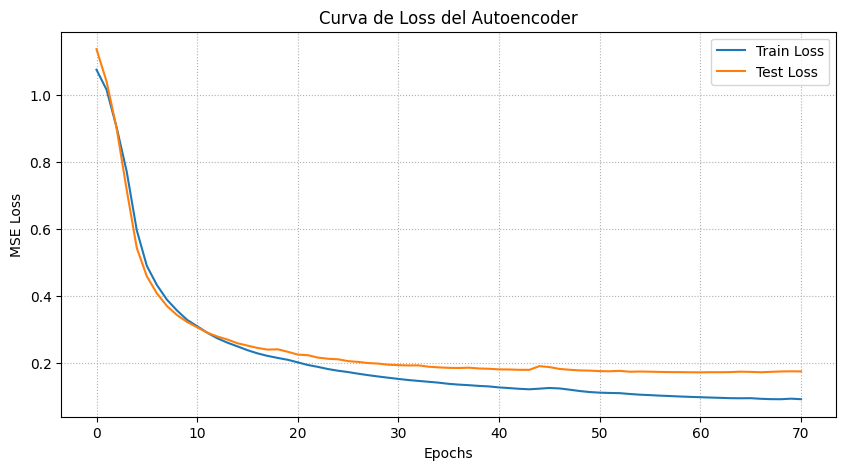

In [39]:
# Gráfico de la Loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.title('Curva de Loss del Autoencoder')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, linestyle=":")
plt.show()


Iniciando comparación visual...
Calculando 80 reconstrucciones con PCA (k=63)...
Calculando 80 reconstrucciones con Autoencoder...
Graficando resultados...


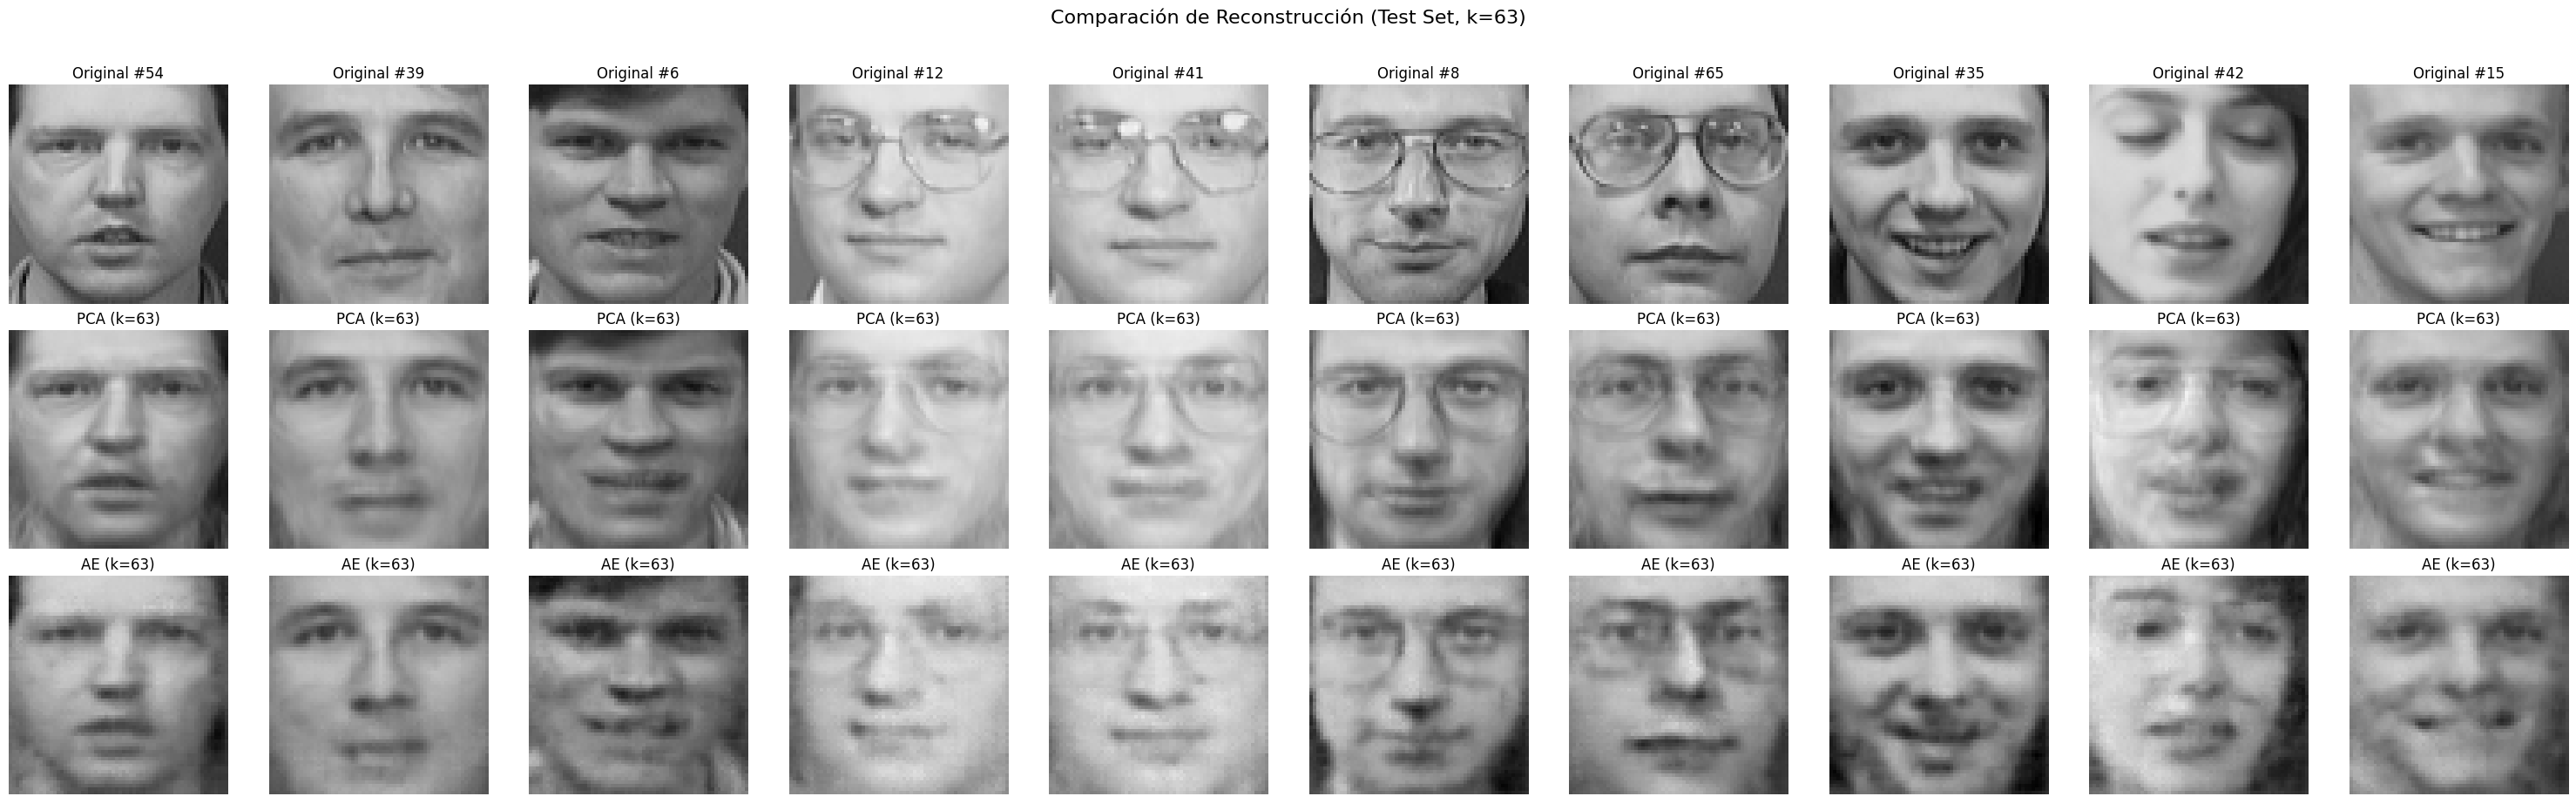

In [40]:
# --- Comparación Visual ---

print("Iniciando comparación visual...")
N_IMAGENES = 10 # Número de imágenes de muestra
plt.figure(figsize=(3 * N_IMAGENES, 9))

# Seleccionamos índices aleatorios del set de 'test'
muestras_idx = np.random.choice(len(test), size=N_IMAGENES, replace=False)

mean_flat = mean.reshape(-1)
std_flat = np.where(std.reshape(-1) == 0, 1.0, std.reshape(-1))

# --- Calcular Reconstrucciones de PCA (para todo 'test') ---
print(f"Calculando {len(test)} reconstrucciones con PCA (k={k_90})...")

# Estandarizamos 'test'
test_std = (test - mean) / np.where(std == 0, 1.0, std)
test_std_flat = test_std.reshape(len(test_std), -1) # (80, 4096)

# Proyectamos y Reconstruimos
test_pca_latente = test_std_flat @ Wk             # (80, 4096) @ (4096, 62) -> (80, 62)
test_pca_rec_std = test_pca_latente @ Wk.T       # (80, 62) @ (62, 4096) -> (80, 4096)

# De-estandarizamos
test_pca_rec_flat = (test_pca_rec_std * std_flat) + mean_flat
pca_reconstructions = test_pca_rec_flat.reshape((-1, 64, 64)) # (80, 64, 64)

    
# --- Calcular Reconstrucciones del Autoencoder (para todo 'test') ---
print(f"Calculando {len(test)} reconstrucciones con Autoencoder...")

model_ae.eval()
with torch.no_grad(): # No necesitamos calcular gradientes
    # Usamos X_test_tensor y lo pasamos por la GPU
    ae_input = X_test_tensor.to(device)
    
    # Obtenemos la salida estandarizada del AE
    ae_output_std_tensor = model_ae(ae_input)

ae_output_std_cpu = ae_output_std_tensor.cpu().numpy()
ae_output_std_cpu = ae_output_std_cpu.squeeze(1) # Quitamos el canal (N, 1, 64, 64) -> (N, 64, 64)

# De-estandarizamos
ae_output_std_flat = ae_output_std_cpu.reshape(len(ae_output_std_cpu), -1)
ae_rec_flat = (ae_output_std_flat * std_flat) + mean_flat
ae_reconstructions = ae_rec_flat.reshape((-1, 64, 64)) # (80, 64, 64)



# --- Graficar la Comparación ---
print("Graficando resultados...")
for i, idx in enumerate(muestras_idx):
    # Fila 1: Original
    ax = plt.subplot(3, N_IMAGENES, i + 1)
    ax.imshow(test[idx], cmap='gray', vmin=0, vmax=1)
    ax.set_title(f"Original #{idx}")
    ax.axis('off')

    # Fila 2: Reconstrucción PCA
    ax = plt.subplot(3, N_IMAGENES, i + 1 + N_IMAGENES)
    ax.imshow(np.clip(pca_reconstructions[idx], 0, 1), cmap='gray', vmin=0, vmax=1)
    ax.set_title(f"PCA (k={k_90})")
    ax.axis('off')
    
    # Fila 3: Reconstrucción Autoencoder
    ax = plt.subplot(3, N_IMAGENES, i + 1 + (2 * N_IMAGENES))
    ax.imshow(np.clip(ae_reconstructions[idx], 0, 1), cmap='gray', vmin=0, vmax=1)
    ax.set_title(f"AE (k={k_90})")
    ax.axis('off')

plt.suptitle(f"Comparación de Reconstrucción (Test Set, k={k_90})", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

Algo que noto es que en PCA parece todas las imagenes tener una sombra de anteojos, mientras que en AE eso no pasa. Algo que pasa en ambos modelos es que en todas las fotos centra la mirada de las personas, aunque en alguna foto original la persona este mirando de costado, en la reconstruccion salen mirando de frente

In [41]:
# --- Creación y Guardado de Datasets ---
# --- Espacio Latente de PCA ---
print("Calculando espacio latente de PCA...")
train_std_flat = train_std.reshape(len(train_std), -1) 
test_std_flat = test_std.reshape(len(test_std), -1)   
X_train_pca = train_std_flat @ Wk
X_test_pca = test_std_flat @ Wk
print(f" - X_train_pca: {X_train_pca.shape}")
# --- Espacio Latente del Autoencoder ---
print("\nCalculando espacio latente del Autoencoder...")
model_ae.eval()
with torch.no_grad():
    ae_input_train = X_train_tensor.to(device)
    latent_train = model_ae.encode(ae_input_train)
    ae_input_test = X_test_tensor.to(device)
    latent_test = model_ae.encode(ae_input_test)
X_train_ae = latent_train.cpu().numpy()
X_test_ae = latent_test.cpu().numpy()
print(f" - X_train_ae: {X_train_ae.shape}")
# --- Verificación de Etiquetas ---
print("\nVerificando etiquetas (labels)...")
if 'y_train' not in locals() or 'y_test' not in locals():
    raise NameError("No se encontraron 'y_train' o 'y_test'.")

y_train = np.array(y_train)
y_test = np.array(y_test)

print(f" - y_train (etiquetas): {y_train.shape}") # Debería ser (320,)
print(f" - y_test (etiquetas):  {y_test.shape}") # Debería ser (80,)
# --- Guardar todo en un archivo .npz ---
FILE_NAME = 'clustering_datasets.npz'
print(f"\nGuardando todos los arrays en '{FILE_NAME}'...")

np.savez(
    FILE_NAME,
    X_train_pca=X_train_pca,
    X_test_pca=X_test_pca,
    X_train_ae=X_train_ae,
    X_test_ae=X_test_ae,
    y_train=y_train,
    y_test=y_test
)
    


Calculando espacio latente de PCA...
 - X_train_pca: (320, 63)

Calculando espacio latente del Autoencoder...
 - X_train_ae: (320, 63)

Verificando etiquetas (labels)...
 - y_train (etiquetas): (320,)
 - y_test (etiquetas):  (80,)

Guardando todos los arrays en 'clustering_datasets.npz'...


Cargando datos desde 'clustering_datasets.npz'...

Buscando K óptimo para K-Means (PCA)...
  K=5: Silhouette=0.1169
  K=6: Silhouette=0.1071
  K=7: Silhouette=0.1050
  K=8: Silhouette=0.1229
  K=9: Silhouette=0.1083
  K=10: Silhouette=0.1046
  K=11: Silhouette=0.1129
  K=12: Silhouette=0.0969
  K=13: Silhouette=0.1285
  K=14: Silhouette=0.1287
  K=15: Silhouette=0.1300
  K=16: Silhouette=0.1287
  K=17: Silhouette=0.1182
  K=18: Silhouette=0.1106
  K=19: Silhouette=0.1123
  K=20: Silhouette=0.1166
✅ ¡Mejor K encontrado para K-Means (PCA): K=15 (Score=0.1300)


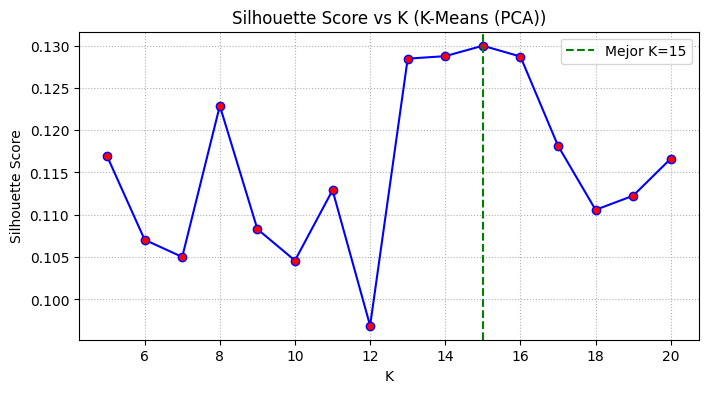


Buscando K óptimo para GMM (PCA)...
  K=5: Silhouette=0.0420
  K=6: Silhouette=0.0269
  K=7: Silhouette=0.0681
  K=8: Silhouette=0.0711
  K=9: Silhouette=0.0485
  K=10: Silhouette=0.0661
  K=11: Silhouette=0.0648
  K=12: Silhouette=0.0660
  K=13: Silhouette=0.0757
  K=14: Silhouette=0.0794
  K=15: Silhouette=0.0907
  K=16: Silhouette=0.1168
  K=17: Silhouette=0.1139
  K=18: Silhouette=0.0746
  K=19: Silhouette=0.0929
  K=20: Silhouette=0.0968
✅ ¡Mejor K encontrado para GMM (PCA): K=16 (Score=0.1168)


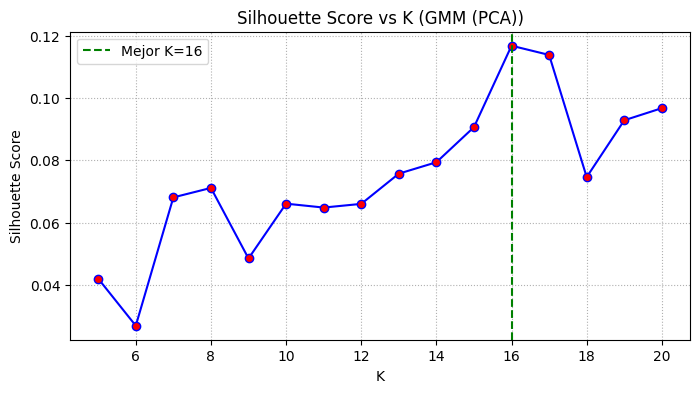


Buscando K óptimo para K-Means (AE)...
  K=5: Silhouette=0.0910
  K=6: Silhouette=0.0776
  K=7: Silhouette=0.0812
  K=8: Silhouette=0.0882
  K=9: Silhouette=0.1002
  K=10: Silhouette=0.0973
  K=11: Silhouette=0.0900
  K=12: Silhouette=0.0854
  K=13: Silhouette=0.1086
  K=14: Silhouette=0.1142
  K=15: Silhouette=0.1151
  K=16: Silhouette=0.1286
  K=17: Silhouette=0.1123
  K=18: Silhouette=0.1264
  K=19: Silhouette=0.1079
  K=20: Silhouette=0.1144
✅ ¡Mejor K encontrado para K-Means (AE): K=16 (Score=0.1286)


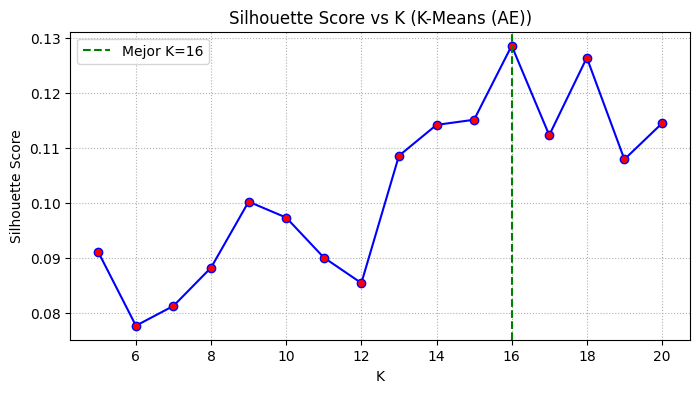


Buscando K óptimo para GMM (AE)...
  K=5: Silhouette=0.0897
  K=6: Silhouette=0.0773
  K=7: Silhouette=0.0818
  K=8: Silhouette=0.0815
  K=9: Silhouette=0.0939
  K=10: Silhouette=0.0992
  K=11: Silhouette=0.0875
  K=12: Silhouette=0.0882
  K=13: Silhouette=0.1065
  K=14: Silhouette=0.1126
  K=15: Silhouette=0.1114
  K=16: Silhouette=0.1288
  K=17: Silhouette=0.1149
  K=18: Silhouette=0.1285
  K=19: Silhouette=0.1058
  K=20: Silhouette=0.1160
✅ ¡Mejor K encontrado para GMM (AE): K=16 (Score=0.1288)


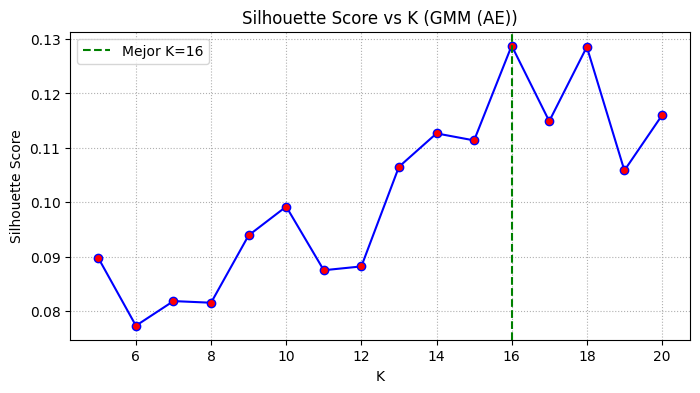


 EVALUACIÓN FINAL CON TEST SET (Usando K óptimos)
Evaluando K-Means (PCA) con K=15...
Evaluando GMM (PCA) con K=16...
Evaluando K-Means (AE) con K=16...
Evaluando GMM (AE) con K=16...

-------------------------------------------------------------------------------------
Modelo          | K   | ARI      | NMI      | Homogeneidad | Completitud 
-------------------------------------------------------------------------------------
K-Means (PCA)   | 15  | 0.1323   | 0.6514   | 0.5443       | 0.8109      
GMM (PCA)       | 16  | 0.1514   | 0.6883   | 0.5668       | 0.8762      
K-Means (AE)    | 16  | 0.1610   | 0.6909   | 0.5911       | 0.8313      
GMM (AE)        | 16  | 0.1768   | 0.6892   | 0.5803       | 0.8484      
-------------------------------------------------------------------------------------


In [42]:
# --- Clustering Automatizado y Evaluación ---

import numpy as np
import matplotlib.pyplot as plt
from kMeans import KMeans
from GMM import GMM
from metrics import silhouette_score, adjusted_rand_index, normalized_mutual_info_score, homogeneity_completeness_v_measure

# Cargar Datos
FILE_NAME = 'clustering_datasets.npz'
print(f"Cargando datos desde '{FILE_NAME}'...")
data = np.load(FILE_NAME)
X_train_pca = data['X_train_pca']
X_test_pca  = data['X_test_pca']
X_train_ae  = data['X_train_ae']
X_test_ae   = data['X_test_ae']
y_train     = data['y_train']
y_test      = data['y_test']

# Función para encontrar el mejor K automáticamente
def find_best_k_silhouette(X, ModelClass, k_range, model_name):
    """
    Entrena modelos para varios K, calcula Silhouette, grafica y devuelve el mejor K.
    """
    print(f"\nBuscando K óptimo para {model_name}...")
    scores = []
    
    for k in k_range:
        # Entrenar
        model = ModelClass(n_clusters=k, random_state=42)
        model.fit(X)
        
        # Predecir etiquetas (usamos los mismos datos de train para silhouette interno)
        labels = model.predict(X)
        
        # Calcular Silhouette
        score = silhouette_score(X, labels)
        scores.append(score)
        print(f"  K={k}: Silhouette={score:.4f}")
        
    # Encontrar el mejor K (el que tiene el score más alto)
    best_idx = np.argmax(scores)
    best_k = k_range[best_idx]
    best_score = scores[best_idx]
    
    print(f"✅ ¡Mejor K encontrado para {model_name}: K={best_k} (Score={best_score:.4f})")
    
    plt.figure(figsize=(8, 4))
    plt.plot(k_range, scores, 'bo-', markerfacecolor='red')
    plt.axvline(best_k, color='green', linestyle='--', label=f'Mejor K={best_k}')
    plt.title(f'Silhouette Score vs K ({model_name})')
    plt.xlabel('K')
    plt.ylabel('Silhouette Score')
    plt.legend()
    plt.grid(True, linestyle=':')
    plt.show()
    
    return best_k

# --- Búsqueda Automática de K ---
k_range = range(5, 21) # Probamos de 5 a 20 clusters

# Buscamos el mejor K para cada combinación

k_pca_kmeans = find_best_k_silhouette(X_train_pca, KMeans, k_range, "K-Means (PCA)")
k_pca_gmm    = find_best_k_silhouette(X_train_pca, GMM,    k_range, "GMM (PCA)")

k_ae_kmeans  = find_best_k_silhouette(X_train_ae,  KMeans, k_range, "K-Means (AE)")
k_ae_gmm     = find_best_k_silhouette(X_train_ae,  GMM,    k_range, "GMM (AE)")


# --- Evaluación Final (Usando los K óptimos encontrados) ---
print("\n" + "="*60)
print(" EVALUACIÓN FINAL CON TEST SET (Usando K óptimos)")
print("="*60)

experiments = [
    ("K-Means (PCA)", KMeans, k_pca_kmeans, X_train_pca, X_test_pca),
    ("GMM (PCA)",     GMM,    k_pca_gmm,    X_train_pca, X_test_pca),
    ("K-Means (AE)",  KMeans, k_ae_kmeans,  X_train_ae,  X_test_ae),
    ("GMM (AE)",      GMM,    k_ae_gmm,     X_train_ae,  X_test_ae)
]

results_table = []

# Preparar y_test para métricas (asegurar enteros y empezar en 0)
y_test_int = y_test.astype(np.int64)
if np.min(y_test_int) > 0:
    y_test_int -= np.min(y_test_int)

for name, ModelClass, k, x_train, x_test in experiments:
    print(f"Evaluando {name} con K={k}...")
    
    # Entrenar modelo final con el mejor K
    model = ModelClass(n_clusters=k, random_state=42)
    model.fit(x_train)
    
    # Predecir en TEST
    labels_pred = model.predict(x_test)
    
    # Calcular métricas externas (contra la verdad y_test)
    ari = adjusted_rand_index(y_test_int, labels_pred)
    nmi = normalized_mutual_info_score(y_test_int, labels_pred)
    hom, compl, _ = homogeneity_completeness_v_measure(y_test_int, labels_pred)
    
    results_table.append((name, k, ari, nmi, hom, compl))

# --- Tabla Resumen ---
print("\n" + "-"*85)
print(f"{'Modelo':<15} | {'K':<3} | {'ARI':<8} | {'NMI':<8} | {'Homogeneidad':<12} | {'Completitud':<12}")
print("-" * 85)

for r in results_table:
    print(f"{r[0]:<15} | {r[1]:<3} | {r[2]:<8.4f} | {r[3]:<8.4f} | {r[4]:<12.4f} | {r[5]:<12.4f}")
print("-" * 85)